In [ ]:

!pip install datasets

In [1]:
from huggingface_hub import HfApi, hf_hub_url
from torchvision import models, transforms
from PIL import Image
import torch
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [ ]:
from datasets import load_dataset

dataset = load_dataset("keremberke/shoe-classification", "default", revision="refs/convert/parquet")

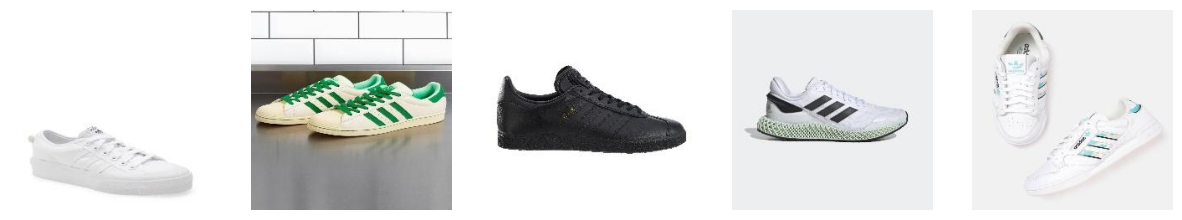

In [7]:

def show_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        img = dataset["train"][i]["image"]
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

show_images(dataset)

In [8]:

def preprocess_image(image):
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return preprocess(image).unsqueeze(0)

In [9]:

model = models.alexnet(pretrained=True)
model.eval()


/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /Users/igyeongseob/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:15<00:00, 15.3MB/s] 


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [28]:
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [10]:

def get_embedding(image, model):
    with torch.no_grad():
        return model(preprocess_image(image)).numpy().flatten()

In [11]:

model.classifier[6] = torch.nn.Identity()
embeddings = [get_embedding(dataset["train"][i]["image"], model) for i in range(len(dataset["train"]))]

In [12]:
embeddings[0].shape

(4096,)

In [13]:

nn_model = NearestNeighbors(n_neighbors=6, algorithm='ball_tree')
nn_model.fit(embeddings)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [14]:

def retrieve_images(index, nn_model, dataset):
    index = int(index)

    distances, indices = nn_model.kneighbors([embeddings[index]])

    indexed_distances = [(int(i), dist) for i, dist in zip(indices[0], distances[0]) if i != index]

    indexed_distances.sort(key=lambda x: x[1])

    retrieved_images = [dataset["train"][idx]["image"] for idx, _ in indexed_distances]
    return retrieved_images

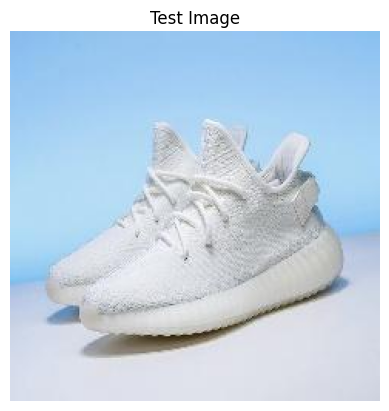

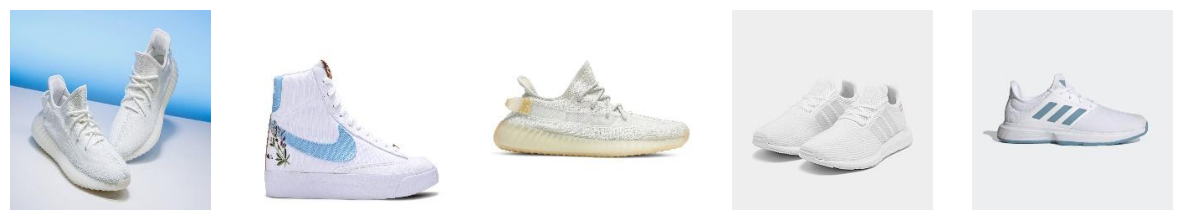

In [31]:
test_index= 94
retrieved_images = retrieve_images(test_index, nn_model, dataset)

plt.imshow(dataset["train"][test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

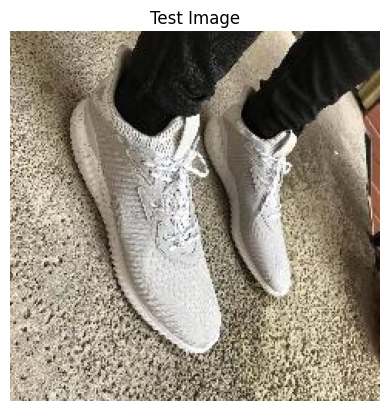

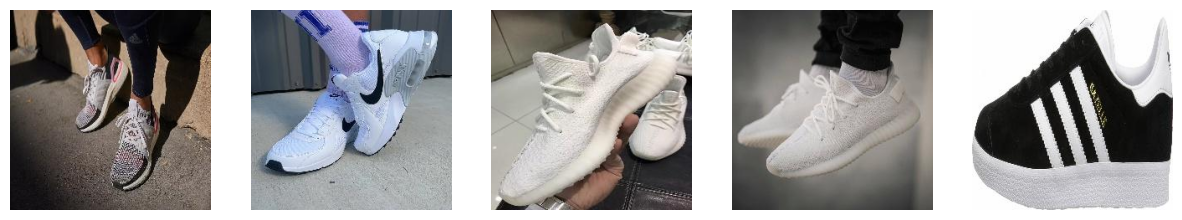

In [16]:
test_index= 65
retrieved_images = retrieve_images(test_index, nn_model, dataset)

plt.imshow(dataset["train"][test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

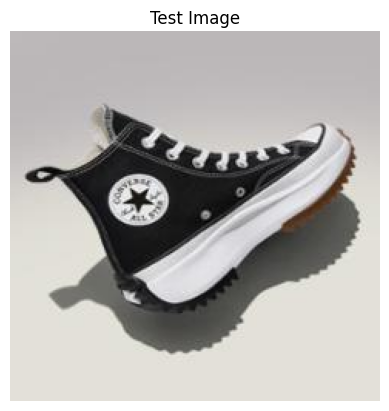

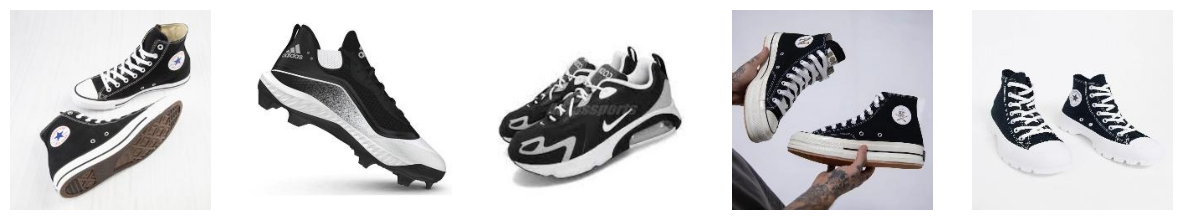

In [17]:
test_index= 358
retrieved_images = retrieve_images(test_index, nn_model, dataset)
plt.imshow(dataset["train"][test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

# Deeper model

In [19]:
def get_embedding(image, model):
    with torch.no_grad():
        output = model(preprocess_image(image))
        return output.cpu().numpy().flatten()

In [20]:

model2 = models.resnet152(pretrained=True)
model2.eval()

/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /Users/igyeongseob/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:16<00:00, 14.6MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [21]:
model2.fc = torch.nn.Identity()
embeddings2 = [get_embedding(dataset["train"][i]["image"], model2) for i in range(len(dataset["train"]))]

In [32]:
embeddings2[0].shape

(2048,)

In [22]:
nn_model2 = NearestNeighbors(n_neighbors=6, algorithm='ball_tree')
nn_model2.fit(embeddings2)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [24]:

def retrieve_images2(index, nn_model, dataset):
    index = int(index)

    distances, indices = nn_model.kneighbors([embeddings2[index]])

    indexed_distances = [(int(i), dist) for i, dist in zip(indices[0], distances[0]) if i != index]

    indexed_distances.sort(key=lambda x: x[1])

    retrieved_images = [dataset["train"][idx]["image"] for idx, _ in indexed_distances]
    return retrieved_images

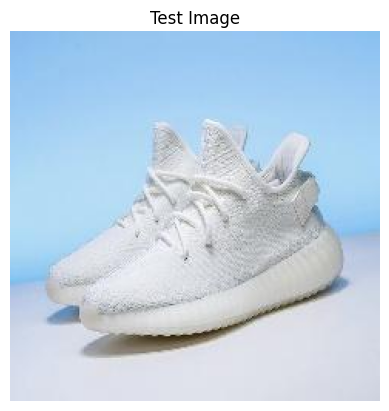

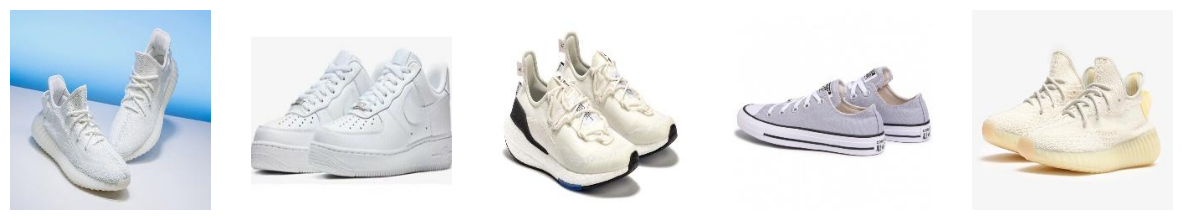

In [25]:
test_index= 94
retrieved_images = retrieve_images2(test_index, nn_model2, dataset)
plt.imshow(dataset["train"][test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

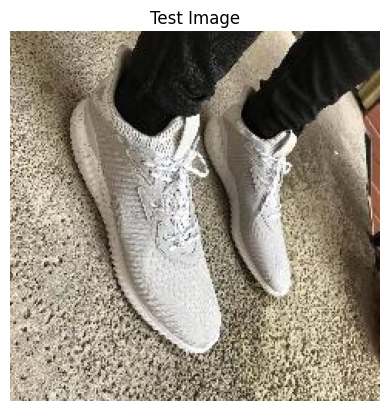

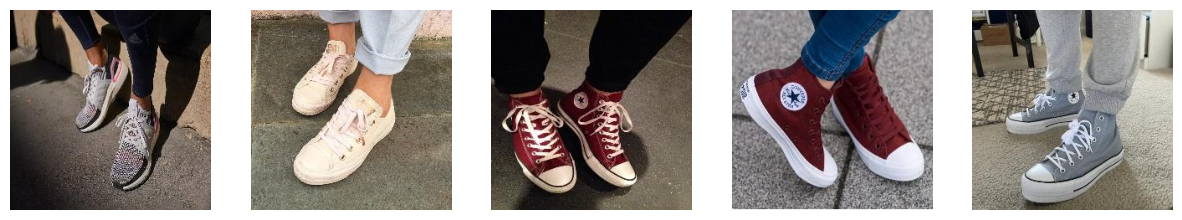

In [26]:
test_index= 65
retrieved_images = retrieve_images2(test_index, nn_model2, dataset)
plt.imshow(dataset["train"][test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

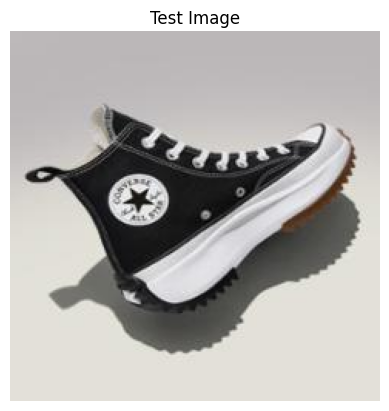

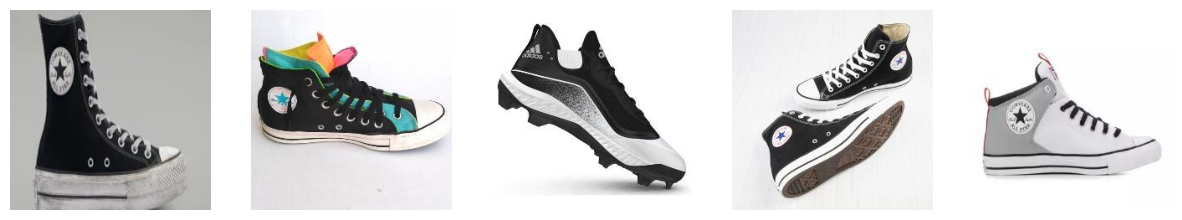

In [33]:
test_index= 358
retrieved_images = retrieve_images2(test_index, nn_model2, dataset)
plt.imshow(dataset["train"][test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})